In [2]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import interp1d

# --- Third-party imports ---
from lifelines.utils import concordance_index

from sksurv.metrics import cumulative_dynamic_auc
from sksurv.util import Surv

from sklearn.metrics import brier_score_loss


In [3]:
beta_sj = pd.read_csv('/hovestadtlab/sabina/methylation-survival/data/beta_sjmb03.csv', index_col=0 )

In [4]:
beta_sj

,101279430012_R01C02,101279430012_R02C02,101279430012_R03C01,101279430012_R03C02,101279430012_R04C01,101279430012_R04C02,101279430012_R05C01,101279430012_R05C02,101279430012_R06C01,101279430012_R06C02,...,9934987115_R02C02,9934987115_R03C01,9934987115_R03C02,9934987115_R04C01,9934987115_R04C02,9934987115_R05C01,9934987115_R05C02,9934987115_R06C01,9934987136_R04C02,9934987136_R05C02
cg21870274,0.600098,0.574401,0.715085,0.359745,0.856042,0.810878,0.698829,0.656744,0.588876,0.681028,...,0.869090,0.471552,0.775650,0.849546,0.718498,0.439816,0.782671,0.353915,0.915338,0.745028
cg08258224,0.699815,0.853425,0.771581,0.174818,0.645697,0.577509,0.764778,0.825359,0.584083,0.726203,...,0.894559,0.804845,0.684367,0.603591,0.783162,0.792787,0.750124,0.464593,0.886142,0.504602
cg16619049,0.119508,0.177358,0.131277,0.145380,1.000000,0.145408,0.093583,0.152863,0.128128,0.105792,...,0.154038,0.179867,0.117947,0.110644,0.107644,0.141264,0.294021,0.125381,0.136595,0.075006
cg13938959,0.778627,0.690554,0.734519,0.208133,0.514864,0.552925,0.881817,0.681751,0.275396,0.788780,...,0.679937,0.664992,0.783681,0.815885,0.624601,0.711436,0.664775,0.765961,0.557830,0.700734
cg12445832,0.379405,0.396545,0.353439,0.147539,0.128648,0.206545,0.714565,0.178930,0.149377,0.546772,...,0.166706,0.257494,0.220055,0.465451,0.400383,0.198575,0.346612,0.452299,0.307758,0.289371
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
cg05615487,0.733422,0.637945,0.608688,0.464763,0.558630,0.497187,0.896134,0.688079,0.866182,0.869163,...,0.887987,0.665226,0.741978,0.801384,0.736872,0.545957,0.872312,0.490706,0.570758,0.885632
cg22122449,0.670336,0.798284,0.384735,0.403808,0.448003,0.758265,0.836240,0.665478,0.548090,0.806575,...,0.638936,0.655490,0.511405,0.554607,0.744648,0.464206,0.870537,0.494671,0.539128,0.776140
cg08423507,0.635853,0.168126,0.396870,0.118158,0.205791,0.159060,0.607683,0.191470,0.511771,0.575537,...,0.657228,0.615336,0.637778,0.424757,0.802222,0.517965,0.844344,0.026035,0.565876,0.682882
cg09007244,0.028795,0.031535,0.034631,0.028236,0.059799,0.099947,0.045642,0.028598,0.064332,0.062963,...,0.036824,0.044292,0.088360,0.026634,0.040888,0.028525,0.075055,0.051701,0.064915,0.036544


In [5]:
cnv_sj = pd.read_csv('data/CNV_gene_sjmb03_20240111.csv', index_col=0)

In [6]:
cnv_sj

,101279430012_R01C02,101279430012_R02C02,101279430012_R03C01,101279430012_R03C02,101279430012_R04C01,101279430012_R04C02,101279430012_R05C01,101279430012_R05C02,101279430012_R06C01,101279430012_R06C02,...,9934987115_R02C02,9934987115_R03C01,9934987115_R03C02,9934987115_R04C01,9934987115_R04C02,9934987115_R05C01,9934987115_R05C02,9934987115_R06C01,9934987136_R04C02,9934987136_R05C02
gene,,,,,,,,,,,,,,,,,,,,,
SAMD11,-0.213245,0.073571,-0.061256,-0.188096,-0.058049,-0.228786,-0.112480,-0.133297,-0.322946,-0.034615,...,-0.093283,0.043267,-0.013143,-0.085467,-0.029107,-0.043358,-0.180804,-0.014870,0.147100,0.280929
NOC2L,-0.129932,0.176552,0.036501,0.068101,-0.034764,0.064833,-0.064769,-0.092141,-0.185126,-0.043925,...,-0.079957,-0.039467,-0.057478,-0.094628,-0.000529,-0.004972,-0.020281,-0.021782,0.019524,-0.009997
KLHL17,-0.441146,0.077854,-0.052173,-0.210979,0.066099,-0.234101,-0.049128,-0.131271,-0.448128,-0.100160,...,-0.122080,0.031830,-0.022150,-0.072356,-0.040919,-0.023770,-0.156683,-0.041957,0.117089,0.372676
PLEKHN1,-0.462124,0.118589,-0.031787,-0.343975,-0.092177,-0.300927,-0.048349,-0.105498,-0.521523,-0.025688,...,-0.113930,0.041943,0.040680,-0.088070,-0.043329,-0.026647,-0.110522,0.026817,0.100670,0.215742
PERM1,-0.387108,0.146570,-0.057591,-0.298946,-0.088141,-0.203603,-0.128435,-0.157472,-0.532046,-0.013616,...,-0.133657,-0.011944,-0.078268,-0.045725,-0.044551,-0.066115,0.018372,-0.030303,0.055135,0.157427
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CHKB,-0.028343,0.146098,0.035140,0.102814,0.058847,0.143763,0.077742,0.055941,0.084439,-0.003106,...,-0.040530,0.030234,0.041718,0.038126,0.110651,0.077530,0.065643,0.085529,0.063178,0.282602
MAPK8IP2,-0.218923,-0.061012,-0.017335,-0.150402,-0.029497,-0.005733,-0.042721,-0.161546,-0.300983,-0.129041,...,-0.088889,-0.053430,-0.013746,-0.155305,-0.066029,-0.068528,0.041062,-0.023419,-0.027724,0.098760
ARSA,-0.271384,0.066366,-0.081672,-0.071081,-0.035812,-0.154215,-0.040674,-0.143635,-0.137197,-0.041404,...,-0.061936,-0.018742,-0.022646,-0.117401,0.058160,0.007698,0.003701,0.021110,0.126509,0.228114


In [4]:
beta_clin = pd.read_csv('data/clinical_trial_beta.csv', index_col = 0)

In [10]:
sj = beta_clin[meta_clin.loc[meta_clin.cohort == "sjmb03"].index]

In [11]:
acns331 = beta_clin[meta_clin.loc[meta_clin.cohort == "acns331"].index]

In [12]:
acns332 = beta_clin[meta_clin.loc[meta_clin.cohort == "acns332"].index]

In [14]:
acns332.to_csv('data/beta_acns332.csv')
acns331.to_csv('data/beta_acns331.csv')
sj.to_csv('data/beta_sjmb03.csv')

In [2]:
meta_clin = pd.read_csv('data/surv_clinical_trial.csv', index_col = 0)

In [150]:
cnv_acns332 = pd.read_csv('data/CNV_gene_acns332_20240115.csv', index_col=0)
cnv_acns331 = pd.read_csv('data/CNV_gene_acns331_20240115.csv', header = None)
cnv_sjmb03 = pd.read_csv('data/CNV_gene_sjmb03_20240111.csv', header = None)

In [155]:
surv_sj = pd.read_csv('data/sjmb03_surv.csv')
cnv_sjmb03.columns = surv_sj['Patient_ID'].values
cnv_sjmb03.index = uniq_gene.name
cnv_sjmb03.index.name = 'gene'
cnv_sjmb03.to_csv('data/CNV_gene_sjmb03_20240111.csv')

In [167]:
cnv_acns331 = pd.read_csv('data/CNV_gene_acns331_20240115.csv', header = None)
surv_acns331 = pd.read_csv('data/acns331_surv.csv')
cnv_acns331.columns = surv_acns331['Patient_ID'].values
cnv_acns331.index = uniq_gene.name
cnv_acns331.index.name = 'gene'
cnv_acns331.to_csv('data/CNV_gene_acns331_20240115.csv')

In [168]:
combined_cnv = pd.concat([cnv_sjmb03, cnv_acns331, cnv_acns332], axis=1)

In [172]:
meta_clin

,time,event,m,pfs_time,pfs_event,cohort,age,subgroup,subtype
samplename,,,,,,,,,
101279430012_R01C02,12.510000,0,0,12.510000,0,sjmb03,10.4466,"MB, G4",VII
101279430012_R02C02,1.188227,1,0,1.149897,1,sjmb03,11.1644,"MB, SHH CHL AD",NaN
101279430012_R03C01,12.510000,0,0,12.510000,0,sjmb03,7.5781,"MB, G4",VII
101279430012_R03C02,1.122519,1,1,0.684463,1,sjmb03,7.0904,"MB, G3",II
101279430012_R04C01,12.510000,0,0,12.510000,0,sjmb03,10.2521,"MB, WNT",NaN
...,...,...,...,...,...,...,...,...,...
202816900074_R01C01,10.479452,0,0,10.479452,0,acns332,5.5000,"MB, SHH INF",NaN
202787550034_R06C01,6.797260,0,0,6.797260,0,acns332,7.9000,"MB, G3",VII
202234380004_R07C01,0.810959,1,1,0.704110,1,acns332,6.0000,"MB, G3",III


In [180]:
surv_preds = pd.read_csv('results/clinical_trial_preds.csv', index_col = 0)

In [185]:


acns332_preds = surv_preds.loc[meta_clin.loc[meta_clin.cohort == "acns332"].index]
acns332_preds.to_csv('results/acns332_preds_integrated.csv')

In [173]:

meta_clin

desired_order = meta_clin.index.tolist()
combined_cnv = combined_cnv[desired_order]

In [175]:
combined_cnv.to_csv('data/combined_cnv_clinical_trials.csv')

In [12]:
# relapse_pred = pd.read_csv('/hovestadtlab/sabina/methylation-survival/results/relapse_predictions.csv', index_col = 0)
# relapse_pred = pd.read_csv('/hovestadtlab/sabina/methylation-survival/results/relapse_predictions_met.csv', index_col = 0)
time_bins = np.array([0, 1.9167e-02, 3.3333e-01, 5.8470e-01, 7.5000e-01, 9.4167e-01, 1.1667,1.5000e+00, 1.8333e+00, 2.0833e+00, 2.5833e+00, 3.2500e+00, 3.9000e+00,5.6667e+00, 8.2875e+00, 2.2000e+01])

In [42]:
relapse_pred_both = pd.read_csv('/hovestadtlab/sabina/methylation-survival/revisions/relapsed_survpreds_both_20260330.csv', header=None)
relapse_pred_both.index = relapse_pred.index
time_bins = np.array([0, 1.9167e-02, 3.3333e-01, 5.8470e-01, 7.5000e-01, 9.4167e-01, 1.1667e+00,
        1.5000e+00, 1.8333e+00, 2.0833e+00, 2.5833e+00, 3.2500e+00, 3.9000e+00,
        5.6667e+00, 8.2875e+00, 2.2000e+01])

In [43]:
relapse_pred_both

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
Patient_ID,,,,,,,,,,,,,,,,
7990895093_R05C02,1.0,0.998182,0.978853,0.904110,0.853004,0.806448,0.764608,0.735283,0.691996,0.652407,0.608871,0.529303,0.479848,0.417051,0.382213,0.059221
9741950085_R06C02,1.0,0.997963,0.974756,0.882636,0.813850,0.753523,0.704786,0.673275,0.629723,0.593047,0.546015,0.462224,0.419180,0.356608,0.323936,0.057563
8622007028_R02C02,1.0,0.999763,0.997519,0.989584,0.983228,0.978257,0.968851,0.958647,0.935856,0.905680,0.869048,0.811793,0.781686,0.716321,0.666304,0.090328
202073220074_R07C01,1.0,0.999909,0.998835,0.995315,0.992441,0.989969,0.984161,0.976686,0.957825,0.929682,0.896791,0.850687,0.824360,0.761690,0.708710,0.105062
9285451180_R03C01,1.0,0.999346,0.992760,0.963190,0.941470,0.920340,0.896007,0.877491,0.842115,0.807499,0.758915,0.664150,0.621123,0.546088,0.497905,0.076526
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9305216139_R06C02,1.0,0.999272,0.992331,0.950868,0.922600,0.889008,0.864155,0.847499,0.824649,0.801448,0.765278,0.692113,0.660859,0.608109,0.570147,0.104184
9305216139_R03C02,1.0,0.999290,0.990373,0.947172,0.913357,0.871929,0.832194,0.804582,0.764615,0.735032,0.679653,0.569105,0.527357,0.451421,0.416620,0.063841
9305216139_R04C02,1.0,0.999038,0.988105,0.942629,0.903453,0.863587,0.826411,0.801007,0.762024,0.728383,0.676597,0.575242,0.532640,0.456746,0.412474,0.060195


In [63]:
rCM_predictions = pd.read_csv('/hovestadtlab/sabina/methylation-survival/results/rCM_predictions.csv', index_col = 0)

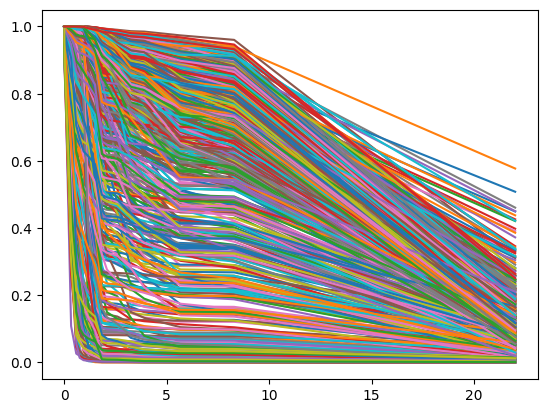

In [64]:
plt.plot(time_bins,rCM_predictions.values.T)
plt.show()

In [44]:
relapse_pred_both.shape

(269, 16)

In [22]:
relapse_pred.shape

(269, 16)

In [26]:
time_bins.shape

(16,)

In [103]:
test_samples = relapse_pred.values
# test_samples = relapse_pred_both.values
# test_samples = rCM_predictions.values
pred_times = time_bins
eval_times = np.arange(0.0, 10.01, 0.1)

n_test_samples = test_samples.shape[0]
interpolated_probs = np.zeros((n_test_samples, len(eval_times)))


for i in range(n_test_samples):
    y_interp = test_samples[i, :]
    interp_func = interp1d(
        pred_times,
        y_interp,
        kind='linear',
        bounds_error=False,
        fill_value=(y_interp[0], y_interp[-1])
    )
    interpolated_probs[i, :] = interp_func(eval_times)

    # force survival at time 0 to be 1
    interpolated_probs[i, np.isclose(eval_times, 0.0)] = 1.0

interpolated_probs = np.clip(interpolated_probs, 0.0, 1.0)

In [ ]:
c = pd.DataFrame(interpolated_probs, index=relapse_pred.index, columns=eval_times)

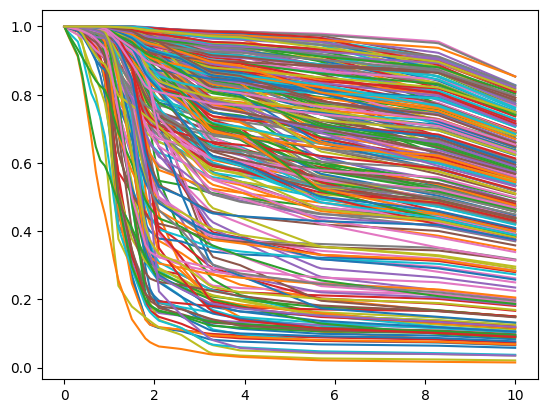

In [104]:
plt.plot(eval_times, interpolated_probs.T)
plt.show()

In [47]:
# relapse_meta = pd.read_csv('full_metadata/Relapse_metadata_ks09182019.txt', sep = '\t', index_col = 0)
relapse_meta = pd.read_csv('full_metadata/relapse_meta_with_mantis_probs_20261703.csv', index_col = 0)
relapse_meta.Exclude_for_pairs.value_counts()
relapse_meta["MANTIS_prob_modelboth"] = interpolated_probs[:, 51]

In [40]:

relapse_meta

,Study_ID,Pair_ID,Patient_ID,Sample_ID,Unique_Project_ID,Manifestation,Cohort,Final_prediction,MNP_Prediction,capper_prediction,...,Age.1,ngs_data,WES_ID,is_relapse_multiple,Exclude_final_cohort,is_primary_multiple,Exclude_for_pairs,Exclude_for_class,MANTIS_prob,MANTIS_prob_modelboth
Sentrix_ID,,,,,,,,,,,,,,,,,,,,,
7990895093_R05C02,relapse_1,pair_1_1,4,MD_MB_199,DKFZ-MB-4_PRIM,Primary,DKFZ,MB_G3,"MB, G3",MB_G3,...,7.000000,NaN,NaN,False,False,False,NaN,NaN,0.546401,0.433640
9741950085_R06C02,relapse_1,pair_1_2,4,P036_67826_diag,DKFZ-MB-4_REL,Relapse,DKFZ,MB_G3,"MB, G3",MB_G3,...,9.000000,NaN,NaN,False,False,False,NaN,NaN,0.453577,0.373137
8622007028_R02C02,relapse_10,pair_10_1,AKMB_17,1M5,AKMB-17_PRIM,Primary,AK,MB_SHH_CHL_AD,"MB, SHH CHL AD",MB_SHH_CHL_AD,...,16.000000,panel,NaN,False,False,False,NaN,NaN,0.933796,0.733588
202073220074_R07C01,relapse_10,pair_10_2,AKMB_17,108858,AKMB-17_REL,Relapse,AK,MB_SHH_CHL_AD,"MB, SHH CHL AD",MB_SHH_CHL_AD,...,32.000000,panel,NaN,False,False,False,NaN,NaN,0.893122,0.778245
9285451180_R03C01,relapse_100,pair_100_1,VR_111,111,VR_111-PRIM,Primary,VJ,MB_G4,"MB, G4",MB_G4,...,5.000000,NaN,NaN,False,False,False,NaN,NaN,0.891395,0.565909
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9305216139_R06C02,relapse_97,pair_97_2,VR_107,107A,VR_107-REL,Relapse,VJ,MB_G3,"MB, G3",MB_G3,...,7.566667,wes,rkr_012,False,False,False,NaN,NaN,0.930044,0.622044
9305216139_R03C02,relapse_98,pair_98_1,VR_109,109,VR_109-PRIM,Primary,VJ,MB_G4,"MB, G4",MB_G4,...,10.100000,wes,rkr_013,False,False,False,NaN,NaN,0.801644,0.471481
9305216139_R04C02,relapse_98,pair_98_2,VR_109,109A,VR_109-REL,Relapse,VJ,MB_G4,"MB, G4",MB_G4,...,11.700000,wes,rkr_014,False,False,False,NaN,NaN,0.774940,0.476794


In [123]:
relapse_meta.to_csv('relapse_meta_with_mantis_probs_m0mplus_20261703.csv')

In [48]:
relapse_meta = relapse_meta.loc[relapse_meta.Exclude_final_cohort == False]
relapse_meta

,Study_ID,Pair_ID,Patient_ID,Sample_ID,Unique_Project_ID,Manifestation,Cohort,Final_prediction,MNP_Prediction,capper_prediction,...,Age.1,ngs_data,WES_ID,is_relapse_multiple,Exclude_final_cohort,is_primary_multiple,Exclude_for_pairs,Exclude_for_class,MANTIS_prob,MANTIS_prob_modelboth
Sentrix_ID,,,,,,,,,,,,,,,,,,,,,
7990895093_R05C02,relapse_1,pair_1_1,4,MD_MB_199,DKFZ-MB-4_PRIM,Primary,DKFZ,MB_G3,"MB, G3",MB_G3,...,7.000000,NaN,NaN,False,False,False,NaN,NaN,0.546401,0.433640
9741950085_R06C02,relapse_1,pair_1_2,4,P036_67826_diag,DKFZ-MB-4_REL,Relapse,DKFZ,MB_G3,"MB, G3",MB_G3,...,9.000000,NaN,NaN,False,False,False,NaN,NaN,0.453577,0.373137
8622007028_R02C02,relapse_10,pair_10_1,AKMB_17,1M5,AKMB-17_PRIM,Primary,AK,MB_SHH_CHL_AD,"MB, SHH CHL AD",MB_SHH_CHL_AD,...,16.000000,panel,NaN,False,False,False,NaN,NaN,0.933796,0.733588
202073220074_R07C01,relapse_10,pair_10_2,AKMB_17,108858,AKMB-17_REL,Relapse,AK,MB_SHH_CHL_AD,"MB, SHH CHL AD",MB_SHH_CHL_AD,...,32.000000,panel,NaN,False,False,False,NaN,NaN,0.893122,0.778245
9285451180_R03C01,relapse_100,pair_100_1,VR_111,111,VR_111-PRIM,Primary,VJ,MB_G4,"MB, G4",MB_G4,...,5.000000,NaN,NaN,False,False,False,NaN,NaN,0.891395,0.565909
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9305216139_R06C02,relapse_97,pair_97_2,VR_107,107A,VR_107-REL,Relapse,VJ,MB_G3,"MB, G3",MB_G3,...,7.566667,wes,rkr_012,False,False,False,NaN,NaN,0.930044,0.622044
9305216139_R03C02,relapse_98,pair_98_1,VR_109,109,VR_109-PRIM,Primary,VJ,MB_G4,"MB, G4",MB_G4,...,10.100000,wes,rkr_013,False,False,False,NaN,NaN,0.801644,0.471481
9305216139_R04C02,relapse_98,pair_98_2,VR_109,109A,VR_109-REL,Relapse,VJ,MB_G4,"MB, G4",MB_G4,...,11.700000,wes,rkr_014,False,False,False,NaN,NaN,0.774940,0.476794


In [66]:
tmp = relapse_meta.copy()

# derive shared pair key and within-pair member
tmp["pair_base"] = tmp["Pair_ID"].str.extract(r"^(pair_\d+)_\d+$")
tmp["pair_member"] = tmp["Pair_ID"].str.extract(r"^pair_\d+_(\d+)$").astype(int)

# keep only complete pairs: member 1 and member 2
pair2 = tmp.groupby("pair_base").filter(
    lambda g: len(g) == 2 and set(g["pair_member"]) == {1, 2}
).copy()

# optional sanity check: _1 should be Primary, _2 should be Relapse
bad_pairs = (
    pair2.pivot(index="pair_base", columns="pair_member", values="Manifestation")
    .rename(columns={1: "member1", 2: "member2"})
)
bad_pairs = bad_pairs[
    (bad_pairs["member1"] != "Primary") |
    (bad_pairs["member2"] != "Relapse")
]

print(bad_pairs)

# mantis_wide = (
#     pair2.pivot(index="pair_base", columns="Manifestation", values="MANTIS_prob_met")
#     .rename(columns={"Primary": "x", "Relapse": "y"})
# )

mantis_wide = (
    pair2.pivot(index="pair_base", columns="Manifestation", values="MANTIS_prob")
    .rename(columns={"Primary": "x", "Relapse": "y"})
)

sample_wide = (
    pair2.pivot(index="pair_base", columns="Manifestation", values="Sample_ID")
    .rename(columns={
        "Primary": "primary_sample",
        "Relapse": "relapse_sample"
    })
)
cohort_wide = (
    pair2.pivot(index="pair_base", columns="Manifestation", values="Cohort")
    .rename(columns={
        "Primary": "primary_cohort",
        "Relapse": "relapse_cohort"
    })
)

cancer_pred_wide = (
    pair2.pivot(index="pair_base", columns="Manifestation", values="Final_prediction")
    .rename(columns={
        "Primary": "primary_cancer_pred",
        "Relapse": "relapse_cancer_pred"
     })
)
pair_xy = (
    mantis_wide
    .join(sample_wide)
    .join(cohort_wide)
    .join(cancer_pred_wide)
    .reset_index()
)

# pair_xy = (
#     mantis_wide.join(sample_wide)
#     [["x", "y", "primary_sample", "relapse_sample"]]
#     .dropna()
#     .reset_index()
# )

pair_xy.head()

Empty DataFrame
Columns: [member1, member2]
Index: []


Manifestation,pair_base,x,y,primary_sample,relapse_sample,primary_cohort,relapse_cohort,primary_cancer_pred,relapse_cancer_pred
0,pair_1,0.546401,0.453577,MD_MB_199,P036_67826_diag,DKFZ,DKFZ,MB_G3,MB_G3
1,pair_10,0.933796,0.893122,1M5,108858,AK,AK,MB_SHH_CHL_AD,MB_SHH_CHL_AD
2,pair_100,0.891395,0.898997,111,111A,VJ,VJ,MB_G4,MB_G4
3,pair_101,0.779961,0.651657,112,112A,VJ,VJ,MB_SHH_INF,MB_SHH_INF
4,pair_102,0.797858,0.830526,113,113A,VJ,VJ,MB_G4,MB_G4


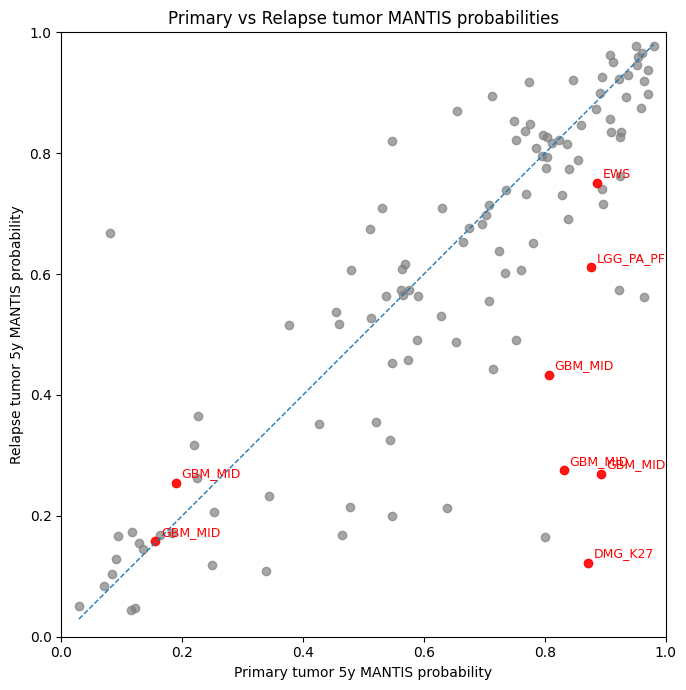

In [120]:
import matplotlib as mpl
import matplotlib.pyplot as plt

# keep text editable in SVG
mpl.rcParams["svg.fonttype"] = "none"

exclude = {
    "MB_G4",
    "MB_SHH_CHL_AD",
    "MB_G3",
    "MB_SHH_INF",
    "MB_WNT",
}

mask = ~pair_xy["relapse_cancer_pred"].isin(exclude)

fig, ax = plt.subplots(figsize=(7, 7))

# non-labeled points
ax.scatter(
    pair_xy.loc[~mask, "x"],
    pair_xy.loc[~mask, "y"],
    color="gray",
    alpha=0.7
)

# highlighted points
ax.scatter(
    pair_xy.loc[mask, "x"],
    pair_xy.loc[mask, "y"],
    color="red",
    alpha=0.9
)

# x = y line
xy_min = min(pair_xy["x"].min(), pair_xy["y"].min())
xy_max = max(pair_xy["x"].max(), pair_xy["y"].max())
ax.plot(
    [xy_min, xy_max],
    [xy_min, xy_max],
    linestyle="--",
    linewidth=1
)

# label highlighted points with relapse_cancer_pred
for _, row in pair_xy.loc[mask, ["x", "y", "relapse_cancer_pred"]].iterrows():
    ax.annotate(
        row["relapse_cancer_pred"],
        (row["x"], row["y"]),
        xytext=(4, 4),
        textcoords="offset points",
        fontsize=9,
        color="red"
    )

ax.set_xlabel("Primary tumor 5y MANTIS probability")
ax.set_ylabel("Relapse tumor 5y MANTIS probability")
ax.set_title("Primary vs Relapse tumor MANTIS probabilities")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

# optional: makes the x=y line visually correct
ax.set_aspect("equal", adjustable="box")

plt.tight_layout()
plt.savefig("primary_vs_recurrent_202060330.svg", format="svg", bbox_inches="tight")
plt.show()

In [67]:
pair_xy.relapse_cancer_pred.value_counts()

relapse_cancer_pred
MB_G4            41
MB_SHH_CHL_AD    36
MB_G3            23
MB_SHH_INF       10
GBM_MID           5
MB_WNT            1
DMG_K27           1
LGG_PA_PF         1
EWS               1
Name: count, dtype: int64

In [99]:
pair_xy.primary_cohort.value_counts()

primary_cohort
VJ            41
AK            27
SJ            14
DKFZ          12
CBTTC          9
SJ_UTSW        7
SJ_CHMN        6
SJ_CHLA        3
SJ_TXCH        2
SJ_Seattle     1
Name: count, dtype: int64

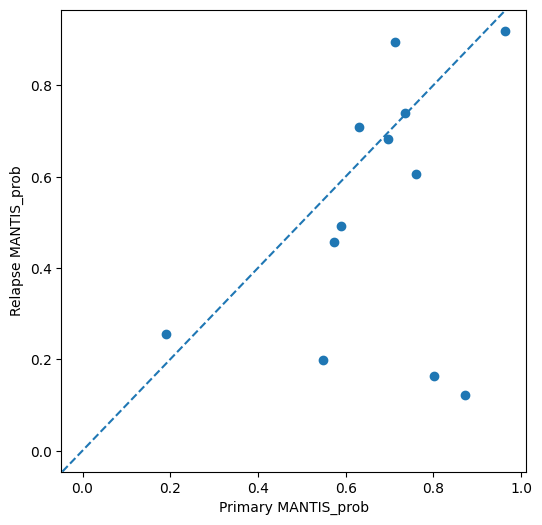

In [78]:
x = pair_xy.loc[pair_xy.primary_cohort == "SJ"].x
y = pair_xy.loc[pair_xy.primary_cohort == "SJ"].y

plt.figure(figsize=(6, 6))
plt.scatter(x, y)
plt.xlabel("Primary MANTIS_prob")
plt.ylabel("Relapse MANTIS_prob")
plt.axline((0, 0), slope=1, linestyle="--")
plt.show()

In [65]:
pair_xy

Manifestation,pair_base,x,y,primary_sample,relapse_sample,primary_cohort,relapse_cohort
0,pair_1,0.546401,0.453577,MD_MB_199,P036_67826_diag,DKFZ,DKFZ
1,pair_10,0.933796,0.893122,1M5,108858,AK,AK
2,pair_100,0.891395,0.898997,111,111A,VJ,VJ
3,pair_101,0.779961,0.651657,112,112A,VJ,VJ
4,pair_102,0.797858,0.830526,113,113A,VJ,VJ
...,...,...,...,...,...,...,...
114,pair_95,0.837132,0.815062,105,105A,VJ,VJ
115,pair_96,0.827924,0.731116,106,106A,VJ,VJ
116,pair_97,0.937545,0.930044,107,107A,VJ,VJ
117,pair_98,0.801644,0.774940,109,109A,VJ,VJ


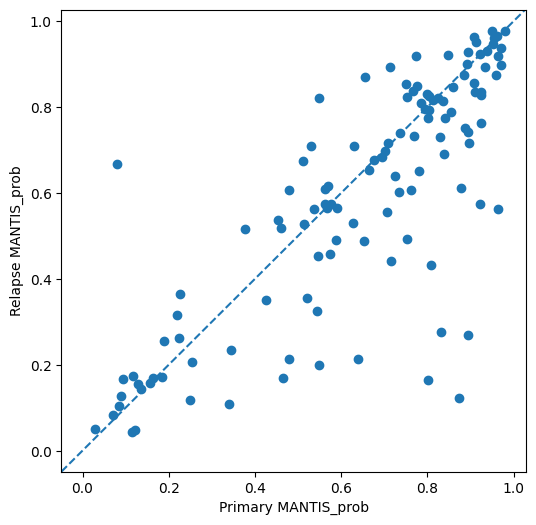

In [64]:
plt.figure(figsize=(6, 6))
plt.scatter(pair_xy["x"], pair_xy["y"])
plt.xlabel("Primary MANTIS_prob")
plt.ylabel("Relapse MANTIS_prob")
plt.axline((0, 0), slope=1, linestyle="--")
plt.show()

(array([ 3.,  1.,  5.,  7., 22., 58., 20.,  2.,  0.,  1.]),
 array([-0.74953716, -0.61580505, -0.48207294, -0.34834082, -0.21460871,
        -0.0808766 ,  0.05285551,  0.18658762,  0.32031974,  0.45405185,
         0.58778396]),
 <BarContainer object of 10 artists>)

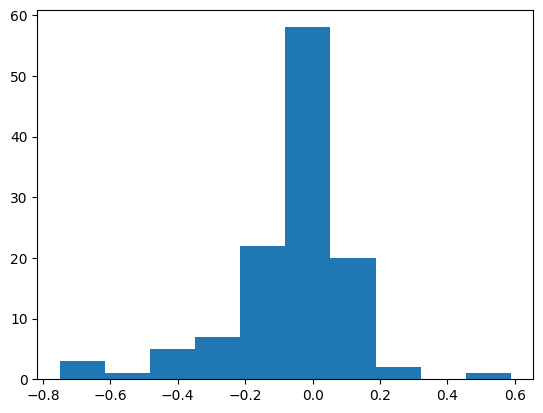

In [79]:
plt.hist(pair_xy["y"] - pair_xy["x"])

In [83]:
# hits = pair_xy.loc[pair_xy["y"] > (pair_xy["x"] + 0.4)].copy()
hits = pair_xy.loc[pair_xy["x"] > (pair_xy["y"] + 0.3)].copy()
sample_ids = pd.unique(
    hits[["primary_sample", "relapse_sample"]].to_numpy().ravel()
)

rows = relapse_meta[relapse_meta["Sample_ID"].isin(sample_ids)].copy()
rows

,Study_ID,Pair_ID,Patient_ID,Sample_ID,Unique_Project_ID,Manifestation,Cohort,Final_prediction,MNP_Prediction,capper_prediction,...,Age.1,ngs_data,WES_ID,is_relapse_multiple,Exclude_final_cohort,is_primary_multiple,Exclude_for_pairs,Exclude_for_class,MANTIS_prob,MANTIS_prob_modelboth
Sentrix_ID,,,,,,,,,,,,,,,,,,,,,
9341679059_R04C01,relapse_117,pair_117_1,VR_128,128,VR_128-PRIM,Primary,VJ,MB_SHH_CHL_AD,"MB, SHH CHL AD",MB_SHH_CHL_AD,...,18.00,NaN,NaN,False,False,False,NaN,NaN,0.638189,0.629513
9341679059_R05C01,relapse_117,pair_117_2,VR_128,128A,VR_128-REL,Relapse,VJ,MB_SHH_CHL_AD,"MB, SHH CHL AD",MB_SHH_CHL_AD,...,18.60,NaN,NaN,False,False,False,NaN,NaN,0.212748,0.455251
9341679004_R05C01,relapse_126,pair_126_1,VR_137,137,VR_137-PRIM,Primary,VJ,MB_SHH_CHL_AD,"MB, SHH CHL AD",MB_SHH_CHL_AD,...,NaN,wes,rkr_027,False,False,False,NaN,NaN,0.964407,0.775068
9341679004_R06C01,relapse_126,pair_126_2,VR_137,137A,VR_137-REL,Relapse,VJ,MB_SHH_CHL_AD,"MB, SHH CHL AD",MB_SHH_CHL_AD,...,NaN,wes,rkr_028,False,False,False,NaN,NaN,0.562875,0.552625
9341679085_R01C01,relapse_131,pair_131_1,VR_142,142,VR_142-PRIM,Primary,VJ,MB_SHH_CHL_AD,"MB, SHH CHL AD",MB_SHH_CHL_AD,...,36.00,wes,rkr_036,False,False,False,NaN,NaN,0.922390,0.696928
9341679085_R02C01,relapse_131,pair_131_2,VR_142,142A,VR_142-REL,Relapse,VJ,MB_SHH_CHL_AD,"MB, SHH CHL AD",MB_SHH_CHL_AD,...,NaN,wes,rkr_037,False,False,False,NaN,NaN,0.573442,0.605703
201465950001_R05C01,relapse_52,pair_52_1,SJ_MB_12,TB_17_00455,SJ-MB-12_PRIM,Primary,SJ,MB_G4,"MB, G4",MB_G4,...,6.75,wes,rkx031,False,False,False,NaN,NaN,0.800774,0.568156
201465950001_R06C01,relapse_52,pair_52_2,SJ_MB_12,TB_17_00456,SJ-MB-12_REL,Relapse,SJ,MB_G3,"MB, G3",MB_G3,...,8.92,wes,rkx032,False,False,False,NaN,NaN,0.164281,0.229289
201465950001_R07C01,relapse_53,pair_53_1,SJ_MB_14,TB_17_00458,SJ-MB-14_PRIM,Primary,SJ,MB_SHH_CHL_AD,"MB, SHH CHL AD",MB_SHH_CHL_AD,...,10.42,wes,rkx033,False,False,False,NaN,NaN,0.872239,0.612685


In [114]:
interp_probs = pd.read_csv('/hovestadtlab/sabina/methylation-survival/revisions/primary_recurrent_survival_interp.csv', index_col=0)
interp_probs

,t_0,t_0_1,t_0_2,t_0_3,t_0_4,t_0_5,t_0_6,t_0_7,t_0_8,t_0_9,...,t_9_1,t_9_2,t_9_3,t_9_4,t_9_5,t_9_6,t_9_7,t_9_8,t_9_9,t_10
sample,,,,,,,,,,,,,,,,,,,,,
7990895093_R05C02,1.0,0.999471,0.997389,0.995253,0.992561,0.982611,0.969494,0.952091,0.930789,0.912331,...,0.519194,0.518878,0.518561,0.518245,0.517928,0.517611,0.517295,0.516978,0.516662,0.516345
9741950085_R06C02,1.0,0.999193,0.994400,0.989019,0.982236,0.963326,0.940462,0.916187,0.891428,0.870559,...,0.423381,0.423097,0.422813,0.422528,0.422244,0.421960,0.421676,0.421391,0.421107,0.420823
8622007028_R02C02,1.0,0.999993,0.999981,0.999969,0.999954,0.999876,0.999622,0.998764,0.997232,0.995588,...,0.915812,0.915407,0.915002,0.914597,0.914192,0.913788,0.913383,0.912978,0.912573,0.912168
202073220074_R07C01,1.0,0.999995,0.999990,0.999984,0.999977,0.999884,0.999464,0.998021,0.995448,0.992646,...,0.867212,0.866736,0.866260,0.865785,0.865309,0.864833,0.864357,0.863881,0.863406,0.862930
9285451180_R03C01,1.0,0.999987,0.999919,0.999835,0.999725,0.999259,0.998457,0.997107,0.995280,0.993641,...,0.860137,0.859659,0.859182,0.858704,0.858227,0.857749,0.857271,0.856794,0.856316,0.855838
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9305216139_R06C02,1.0,0.999949,0.999726,0.999448,0.998974,0.997554,0.995611,0.993166,0.990369,0.987947,...,0.921983,0.921842,0.921701,0.921560,0.921419,0.921278,0.921137,0.920995,0.920854,0.920713
9305216139_R03C02,1.0,0.999993,0.999943,0.999881,0.999738,0.998874,0.997390,0.994701,0.990897,0.987473,...,0.772189,0.771838,0.771488,0.771137,0.770786,0.770435,0.770084,0.769734,0.769383,0.769032
9305216139_R04C02,1.0,0.999955,0.999758,0.999472,0.998655,0.994489,0.987714,0.978985,0.969263,0.960997,...,0.757315,0.757078,0.756841,0.756604,0.756367,0.756130,0.755893,0.755656,0.755418,0.755181


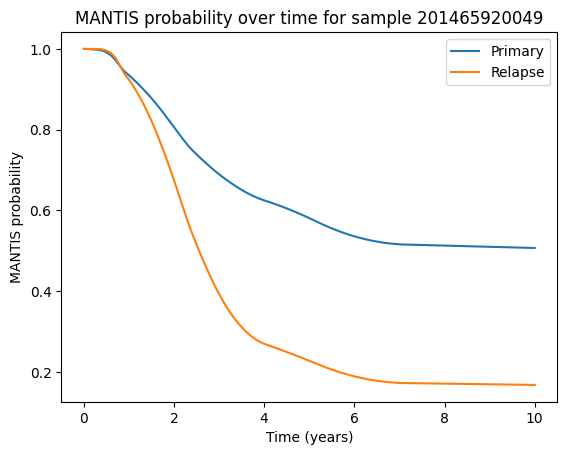

In [118]:
prim = interp_probs.loc["201465920049_R03C01"]
rec = interp_probs.loc["201465920049_R04C01"]
mpl.rcParams["svg.fonttype"] = "none"

plt.plot(eval_times, prim, label="Primary")
plt.plot(eval_times , rec, label="Relapse")
plt.xlabel("Time (years)")
plt.ylabel("MANTIS probability")
plt.title("MANTIS probability over time for sample 201465920049")
plt.legend()
plt.savefig("primary_recurrent_survival_201465920049.svg", format="svg", bbox_inches="tight")
plt.show()

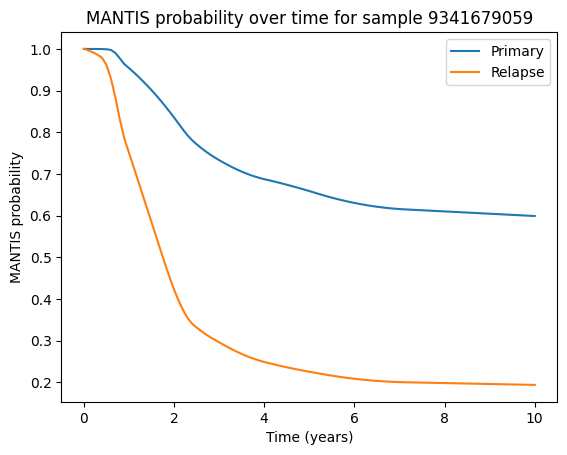

In [119]:



prim = interp_probs.loc["9341679059_R04C01"]
rec = interp_probs.loc["9341679059_R05C01"]

plt.plot(eval_times, prim, label="Primary")
plt.plot(eval_times , rec, label="Relapse")
plt.xlabel("Time (years)")
plt.ylabel("MANTIS probability")
plt.title("MANTIS probability over time for sample 9341679059")
plt.legend()
plt.savefig("primary_recurrent_survival_9341679059.svg", format="svg", bbox_inches="tight")
plt.show()

In [58]:
pair2 = relapse_meta.groupby("Pair_ID").filter(lambda g: len(g) == 2).copy()

# keep only pairs with one Primary and one Relapse
pair2 = pair2.groupby("Pair_ID").filter(
    lambda g: set(g["Manifestation"]) == {"Primary", "Relapse"}
)

# reshape so each row is one pair: x=Primary, y=Relapse
pair_xy = (
    pair2.pivot(index="Pair_ID", columns="Manifestation", values="MANTIS_prob")
    .rename(columns={"Primary": "x", "Relapse": "y"})
    .reset_index()
)

pair_xy.head()

Manifestation,Pair_ID


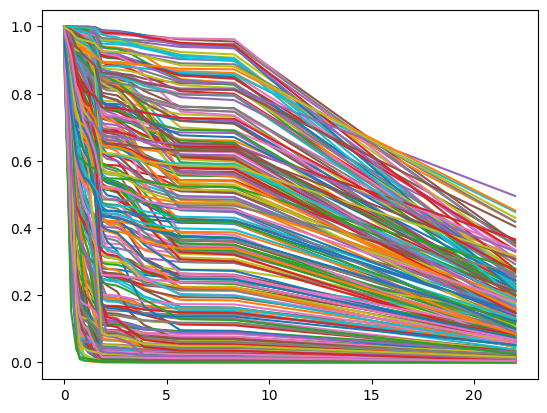

In [59]:
plt.plot(time_bins,relapse_pred.values.T)
plt.show()

In [5]:
uniq_gene = pd.read_csv('uniq_gene_20240101.csv')

In [37]:
beta_relapse = pd.read_csv('data/relapsed_beta_values.csv', index_col = 0)

In [38]:
beta_relapse

,7990895093_R05C02,9741950085_R06C02,8622007028_R02C02,202073220074_R07C01,9285451180_R03C01,9285451180_R04C01,9285451180_R01C01,9285451180_R02C01,9285451180_R01C02,9285451180_R02C02,...,9341679006_R01C02,9341679006_R02C02,9341679014_R03C01,9341679014_R04C01,9305216139_R05C02,9305216139_R06C02,9305216139_R03C02,9305216139_R04C02,9285451180_R05C01,9285451180_R06C01
cg21870274,0.722853,0.683029,0.687491,0.831225,0.868453,0.869024,0.438340,0.441922,0.680456,0.758977,...,0.589259,0.563717,0.829077,0.754902,0.771083,0.545871,0.844617,0.541592,0.747749,0.809680
cg08258224,0.584376,0.688118,0.792970,0.801583,0.811696,0.774990,0.794589,0.773084,0.597067,0.775031,...,0.763893,0.742134,0.630607,0.833407,0.709515,0.623255,0.782254,0.735544,0.716926,0.705809
cg16619049,0.160938,0.074497,0.187111,0.041655,0.110833,0.094178,0.126043,0.164002,0.096635,0.094264,...,0.171280,0.192997,0.221124,0.161020,0.186037,0.165734,0.212355,0.245552,0.080190,0.061044
cg13938959,0.306192,0.204812,0.883219,0.865765,0.725359,0.741597,0.873536,0.862568,0.731437,0.811235,...,0.802559,0.910204,0.838677,0.747435,0.648702,0.631899,0.664060,0.848801,0.775379,0.873566
cg12445832,0.166687,0.084534,0.776106,0.770561,0.528350,0.429469,0.731936,0.727963,0.173822,0.218784,...,0.577099,0.664494,0.563986,0.487846,0.292892,0.173921,0.381975,0.249189,0.429620,0.705202
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
cg05615487,0.617234,0.650152,0.616120,0.609518,0.562309,0.501573,0.457844,0.394727,0.769118,0.644467,...,0.733128,0.778223,0.836170,0.894926,0.834507,0.778487,0.854553,0.889717,0.599833,0.622428
cg22122449,0.590933,0.698869,0.647373,0.570098,0.728105,0.636666,0.424704,0.218674,0.554191,0.856191,...,0.793862,0.687756,0.779518,0.675642,0.634834,0.724157,0.755167,0.826763,0.697500,0.618352
cg08423507,0.238084,0.020313,0.412333,0.181030,0.226408,0.211046,0.079579,0.183628,0.398983,0.754544,...,0.148164,0.181070,0.706747,0.420881,0.349895,0.222761,0.226081,0.304134,0.559662,0.710976
cg09007244,0.167071,0.054213,0.047650,0.048127,0.098744,0.053970,0.039934,0.039033,0.040263,0.041852,...,0.037215,0.039617,0.056879,0.052177,0.035125,0.075707,0.056908,0.048418,0.036021,0.036087


In [41]:
relapse_meta = pd.read_csv('/hovestadtlab/sabina/methylation-survival/full_metadata/Relapse_metadata_ks09182019.txt', sep = '\t', index_col = 0)

In [43]:
np.zeros(len(relapse_meta))

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0.

In [46]:
relapse_meta

pd.DataFrame({"Patient_ID": relapse_meta.index, "m": np.zeros(len(relapse_meta)), "age": relapse_meta["Age.1"]}).set_index("Patient_ID").to_csv('data/relapse_clinical.csv')

In [50]:
cnv_relapse = pd.read_csv('data/relapsed_CNV_gene_values.csv', index_col = 0)

In [9]:
cnv_cavalli = pd.read_csv('data/cnv_cavalli.csv', header = None)

In [55]:
surv_relapse = pd.read_csv('data/relapse_clinical.csv')
cnv_relapse.columns = surv_relapse['Patient_ID'].values
cnv_relapse.index = uniq_gene.name
cnv_relapse.index.name = 'gene'
cnv_relapse.to_csv('data/relapsed_CNV_gene_values.csv')


In [ ]:
cnv_cavalli = pd.read_csv('data/cnv_cavalli.csv', header = None)
surv_cav = pd.read_csv('data/surv_cavalli.csv')
cnv_cavalli.columns = surv_cav['idat'].values
cnv_cavalli.index = uniq_gene.name
cnv_cavalli.index.name = 'gene'
cnv_cavalli.to_csv('data/cnv_cavalli.csv')

In [24]:
cnv_cavalli = pd.read_csv('data/cnv_cavalli.csv',index_col = 0)
cnv_cavalli

,7796806110_R01C01,7796806110_R02C01,7796806110_R04C02,7796806110_R06C01,7810920068_R01C01,7810920068_R01C02,7810920068_R02C01,7810920068_R02C02,7810920068_R03C01,7810920068_R03C02,...,9344737044_R06C01,9344737073_R01C01,9344737073_R03C01,9344737073_R03C02,9344737073_R04C01,9344737073_R05C02,9344737082_R01C02,9344737104_R02C01,9344737104_R05C02,9344737104_R06C01
gene,,,,,,,,,,,,,,,,,,,,,
SAMD11,0.036746,-0.042059,-0.132367,-0.035629,-0.013463,0.100821,0.023560,0.084718,0.021973,-0.001075,...,0.036075,0.013033,0.070144,-0.023379,-0.006933,-0.064484,-0.027112,-0.117748,0.030854,0.017040
NOC2L,0.074550,0.007140,-0.013992,0.064831,-0.096137,0.087142,-0.041087,-0.045735,-0.056567,-0.023292,...,0.117106,0.107650,0.133653,0.131156,-0.008761,0.055979,0.058386,-0.016292,0.189042,0.108550
KLHL17,0.028112,-0.063691,-0.096172,0.023648,-0.049936,0.166430,0.054257,0.063978,-0.057538,0.020698,...,-0.004785,-0.009167,0.017448,0.058759,-0.029008,-0.084954,0.033090,-0.113725,0.049044,0.007953
PLEKHN1,0.088221,-0.007206,-0.096203,-0.010855,-0.022600,0.074987,0.087967,0.109646,-0.125422,0.023932,...,-0.060831,-0.064143,0.138046,-0.000316,0.016855,0.046908,0.082046,-0.033214,0.210133,0.175819
PERM1,-0.177229,-0.037100,-0.108144,-0.111615,-0.130670,0.044987,-0.175156,-0.008103,-0.288944,-0.290247,...,-0.141497,-0.070957,-0.017729,-0.148000,-0.182465,-0.087320,0.030494,-0.168854,0.054541,-0.107504
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CHKB,0.051076,-0.032236,-0.048905,0.099925,-0.032619,0.125447,0.040703,0.096455,0.145098,-0.028940,...,0.156867,-0.032703,0.066985,0.090095,-0.023092,-0.093009,0.129038,0.099433,0.111235,0.031232
MAPK8IP2,-0.049065,-0.025232,-0.079597,0.011649,-0.067075,0.127858,0.072513,0.127746,0.087538,-0.063929,...,0.259174,0.027414,0.060325,0.171818,0.115775,-0.017182,0.109879,0.160141,0.147240,0.165705
ARSA,-0.056735,-0.037812,-0.134772,0.005923,-0.094092,0.137421,0.019865,0.033256,0.027977,-0.171713,...,0.192502,-0.170397,0.027181,-0.048768,-0.012499,-0.236947,0.063536,0.027369,-0.007146,0.085942


In [25]:
cnv_jones = pd.read_csv('data/cnv_jones.csv', header = None)
surv_jones = pd.read_csv('data/surv_jones.csv')
cnv_jones.columns = surv_jones['idat'].values
cnv_jones.index = uniq_gene.name
cnv_jones.index.name = 'gene'
cnv_jones.to_csv('data/cnv_jones.csv')

In [26]:
cnv_northcott = pd.read_csv('data/cnv_northcott.csv', header = None)
surv_northcott = pd.read_csv('data/surv_northcott.csv')
cnv_northcott.columns = surv_northcott['idat'].values
cnv_northcott.index = uniq_gene.name
cnv_northcott.index.name = 'gene'
cnv_northcott.to_csv('data/cnv_northcott.csv')

In [ ]:
cnv_acns332 = pd.read_csv('data/CNV_gene_acns332_20240115.csv', header = None)
surv_acns332 = pd.read_csv('data/acns332_surv.csv')
cnv_acns332.columns = surv_acns332['Patient_ID'].values
cnv_acns332.index = uniq_gene.name
cnv_acns332.index.name = 'gene'
cnv_acns332.to_csv('data/cnv_acns332.csv')

In [131]:
beta_acns332 = pd.read_csv('data/beta_acns332_20240104.csv', header = None)
surv_acns332 = pd.read_csv('data/acns332_surv.csv')
beta_acns332.columns = surv_acns332['Patient_ID'].values
beta_acns332.index = prbs.index
# beta_acns332.to_csv('data/beta_acns332_20240115.csv')

In [133]:
beta_acns332
beta_acns332.to_csv('data/beta_acns332_20240115.csv')

In [134]:
beta_acns332

,201985320035_R02C01,201985320035_R03C01,201985320035_R05C01,201985320035_R06C01,201985320035_R07C01,201985320035_R08C01,202234380036_R01C01,201985320037_R01C01,201985320037_R02C01,201985320037_R03C01,...,202234380004_R02C01,202234380004_R03C01,202234380004_R04C01,202234380004_R05C01,202234380004_R06C01,202816900074_R01C01,202787550034_R06C01,202234380004_R07C01,201980430190_R07C01,202787550034_R03C01
cg21870274,0.406571,0.722250,0.308864,0.878194,0.686602,0.842309,0.901594,0.611156,0.634327,0.509759,...,0.343685,0.521806,0.307675,0.610082,0.524409,0.710573,0.855131,0.519986,0.540355,0.791315
cg08258224,0.513594,0.794590,0.576091,0.845304,0.815792,0.619659,0.585216,0.779020,0.664907,0.690489,...,0.196642,0.703225,0.442056,0.530984,0.517751,0.809749,0.387104,0.414826,0.357302,0.378730
cg16619049,0.091547,0.050065,0.048363,0.048580,0.051603,0.066626,0.032419,0.055961,0.079963,0.056017,...,0.038173,0.033313,0.070794,0.058442,0.043938,0.063928,0.736984,0.121003,0.097693,0.460656
cg13938959,0.735823,0.839342,0.911350,0.877088,0.876664,0.737857,0.827106,0.847466,0.357344,0.835021,...,0.301999,0.815740,0.422569,0.564167,0.619181,0.863342,0.639809,0.736067,0.306851,0.727566
cg12445832,0.303536,0.342888,0.258590,0.719251,0.726902,0.489054,0.206396,0.655553,0.140984,0.597666,...,0.094617,0.200152,0.184376,0.229727,0.087280,0.586632,0.528262,0.337101,0.137638,0.025168
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
cg05615487,0.456984,0.804698,0.814278,0.875246,0.808255,0.644873,0.894464,0.798711,0.690681,0.828269,...,0.408167,0.575151,0.437983,0.813576,0.483535,0.599089,0.184306,0.358564,0.320460,0.317140
cg22122449,0.497789,0.611012,0.204713,0.930700,0.883663,0.439442,0.473175,0.414498,0.584998,0.767651,...,0.218718,0.474435,0.248755,0.450673,0.545164,0.497927,0.389853,0.403168,0.543675,0.302187
cg08423507,0.212059,0.336916,0.260953,0.826215,0.505383,0.143805,0.222454,0.301927,0.439710,0.733552,...,0.156851,0.450227,0.185630,0.670163,0.494119,0.237049,0.604298,0.354373,0.258842,0.333049
cg09007244,0.013781,0.018838,0.012142,0.018516,0.024090,0.025851,0.034740,0.016718,0.049354,0.020290,...,0.053850,0.063212,0.051721,0.058772,0.074534,0.019598,0.312562,0.338422,0.012367,0.168860


In [27]:
cnv_sturm = pd.read_csv('data/cnv_sturm.csv', header = None)
surv_sturm = pd.read_csv('data/surv_sturm.csv')
cnv_sturm.columns = surv_sturm['idat'].values
cnv_sturm.index = uniq_gene.name
cnv_sturm.index.name = 'gene'
cnv_sturm.to_csv('data/cnv_sturm.csv')

In [28]:
cnv_g34_test = pd.read_csv('data/CNV_g34_test.csv', header = None)
surv_g34_test = pd.read_csv('data/group34_rCM_samples.csv')
cnv_g34_test.columns = surv_g34_test['idat'].values
cnv_g34_test.index = uniq_gene.name
cnv_g34_test.index.name = 'gene'
cnv_g34_test.to_csv('data/CNV_g34_test.csv')

In [31]:
relapsed_cnv = pd.read_csv('data/relapsed_CNV_gene_values.csv', index_col = 0)

In [ ]:
beta_cavalli = pd.read_csv('data/beta_cavalli.csv', index_col = 0)


,7796806110_R01C01,7796806110_R02C01,7796806110_R04C02,7796806110_R06C01,7810920068_R01C01,7810920068_R01C02,7810920068_R02C01,7810920068_R02C02,7810920068_R03C01,7810920068_R03C02,...,9344737044_R06C01,9344737073_R01C01,9344737073_R03C01,9344737073_R03C02,9344737073_R04C01,9344737073_R05C02,9344737082_R01C02,9344737104_R02C01,9344737104_R05C02,9344737104_R06C01
cg21870274,0.357720,0.646857,0.720404,0.916192,0.603767,0.637606,0.759358,0.869782,0.801935,0.652322,...,0.536310,0.591601,0.716915,0.478878,0.681219,0.664384,0.702015,0.815227,0.895849,0.819059
cg08258224,0.467129,0.840234,0.807882,0.814786,0.886030,0.875462,0.899187,0.866630,0.528449,0.791275,...,0.541148,0.811135,0.843883,0.610711,0.437202,0.774520,0.667830,0.674494,0.842357,0.830005
cg16619049,0.115626,0.088999,0.076715,0.127258,0.090702,0.126099,0.076010,0.099267,0.097135,0.064628,...,0.089099,0.076603,0.181310,0.123898,0.116785,0.114851,0.056771,0.081724,0.185141,0.079078
cg13938959,0.467549,0.857844,0.692533,0.565313,0.938371,0.905756,0.772168,0.925614,0.506036,0.639403,...,0.524841,0.769252,0.833753,0.492933,0.718458,0.802716,0.852768,0.846323,0.924317,0.735574
cg12445832,0.137186,0.448626,0.441199,0.120930,0.867691,0.797698,0.662613,0.874158,0.093127,0.317814,...,0.130799,0.199232,0.419498,0.292551,0.103023,0.571883,0.328864,0.360864,0.840543,0.525298
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
cg05615487,0.452833,0.587973,0.876637,0.739168,0.906500,0.902781,0.593111,0.474487,0.755855,0.627160,...,0.672074,0.852711,0.846662,0.571958,0.829862,0.877506,0.481380,0.750113,0.898328,0.419729
cg22122449,0.283465,0.729854,0.392769,0.591939,0.884937,0.505579,0.479007,0.431095,0.689929,0.440672,...,0.204616,0.415394,0.806906,0.443603,0.294694,0.688639,0.743394,0.580961,0.807196,0.437202
cg08423507,0.164006,0.650144,0.411097,0.371856,0.253150,0.271160,0.232474,0.174432,0.832952,0.797855,...,0.082634,0.225486,0.218766,0.290789,0.386454,0.559178,0.639584,0.642796,0.110519,0.332451
cg09007244,0.032039,0.032886,0.027708,0.027527,0.026917,0.032067,0.029892,0.032941,0.042264,0.052140,...,0.034474,0.023969,0.027418,0.040322,0.034905,0.025210,0.023720,0.026454,0.039392,0.022539


In [34]:
beta_cavalli.index

Index(['cg21870274', 'cg08258224', 'cg16619049', 'cg13938959', 'cg12445832',
       'cg23999112', 'cg11527153', 'cg04195702', 'cg08128007', 'cg23733394',
       ...
       'cg09635994', 'cg19004771', 'cg20569369', 'cg26034629', 'cg25232725',
       'cg05615487', 'cg22122449', 'cg08423507', 'cg09007244', 'cg19565306'],
      dtype='object', length=357692)

In [23]:
cnv_cavalli.to_csv('data/cnv_cavalli.csv')

In [130]:
prbs = pd.read_csv('data/probe2singlegene_357692probes.vh231024.txt', sep = '\t')

In [17]:
beta_cav = pd.read_csv('data/beta_cavalli.csv', header = None)
surv_cav = pd.read_csv('data/surv_cavalli.csv')

In [19]:
beta_cav.columns = surv_cav['idat'].values
beta_cav.index = prbs.index

In [21]:
beta_cav.to_csv('data/beta_cavalli.csv') #, header = None, index = False)

In [22]:
beta_jones = pd.read_csv('data/beta_jones.csv', header = None)
surv_jones = pd.read_csv('data/surv_jones.csv')
beta_jones.columns = surv_jones['idat'].values
beta_jones.index = prbs.index
beta_jones.to_csv('data/beta_jones.csv')

In [24]:
beta_jones = pd.read_csv('data/beta_jones.csv', index_col = 0)
beta_jones

,6929718001_R04C02,6929793052_R02C02,6929718001_R05C02,6929793052_R03C02,6929793052_R04C02,6969568004_R03C01,6929718001_R06C02,6969568004_R04C01,9855358048_R04C01,6929793052_R05C02,...,9855358053_R03C02,9007217016_R03C02,9007217016_R01C01,9855358053_R05C02,9007217016_R06C01,9007217108_R01C01,9007217108_R03C02,9855358058_R06C02,9855358064_R02C01,9855358064_R03C01
cg21870274,0.828558,0.797897,0.540127,0.717721,0.888237,0.693602,0.714978,0.700579,0.858246,0.763568,...,0.507816,0.927314,0.657935,0.766334,0.924733,0.756275,0.706224,0.890478,0.748062,0.759468
cg08258224,0.694328,0.889895,0.824369,0.697077,0.887639,0.505729,0.490959,0.688932,0.795890,0.792835,...,0.729307,0.589554,0.738631,0.797988,0.895393,0.506489,0.786208,0.877926,0.841497,0.726118
cg16619049,0.072470,0.103672,0.100461,0.095977,0.088752,0.077900,0.048522,0.099229,0.085210,0.242048,...,0.094399,0.091563,0.078951,0.084007,0.071556,0.077594,0.064964,0.035945,0.131942,0.081188
cg13938959,0.420788,0.905422,0.931931,0.753302,0.910836,0.577508,0.658058,0.625285,0.750113,0.911779,...,0.806429,0.828616,0.896175,0.745795,0.545735,0.647585,0.693909,0.868896,0.856130,0.506376
cg12445832,0.223830,0.598983,0.842065,0.504316,0.540841,0.062123,0.104788,0.164624,0.373316,0.832856,...,0.462997,0.471637,0.471856,0.355999,0.197549,0.293858,0.228836,0.125062,0.669126,0.156897
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
cg05615487,0.865918,0.842286,0.857975,0.784140,0.566866,0.854471,0.508163,0.304110,0.654335,0.805792,...,0.613418,0.858147,0.528494,0.706252,0.903227,0.404496,0.785921,0.865392,0.669139,0.855577
cg22122449,0.452144,0.721864,0.608598,0.755282,0.852995,0.525783,0.310720,0.270792,0.379273,0.678310,...,0.372052,0.753960,0.477070,0.625913,0.864155,0.532765,0.383993,0.524466,0.694510,0.550892
cg08423507,0.170059,0.421595,0.272261,0.816392,0.664498,0.432667,0.225058,0.090957,0.127288,0.411195,...,0.096395,0.383587,0.488672,0.490251,0.454768,0.335127,0.573517,0.668801,0.855407,0.630386
cg09007244,0.030424,0.031562,0.032138,0.037195,0.028903,0.029797,0.035189,0.027420,0.043168,0.035186,...,0.037768,0.034016,0.027026,0.054195,0.046992,0.028956,0.036720,0.023534,0.024009,0.041170


In [23]:
beta_sturm = pd.read_csv('data/beta_sturm.csv', header = None)
surv_sturm = pd.read_csv('data/surv_sturm.csv')
beta_sturm.columns = surv_sturm['idat'].values
beta_sturm.index = prbs.index
beta_sturm.to_csv('data/beta_sturm.csv')

In [25]:
beta_northcott = pd.read_csv('data/beta_northcott.csv', header = None)
surv_northcott = pd.read_csv('data/surv_northcott.csv')
beta_northcott.columns = surv_northcott['idat'].values
beta_northcott.index = prbs.index
beta_northcott.to_csv('data/beta_northcott.csv')

In [28]:
beta_sj_average = pd.read_csv('data/beta_sj_average.csv', header = None)
surv_sj_average = pd.read_csv('data/surv_sj_average.csv')
beta_sj_average.columns = surv_sj_average['Patient_ID'].values
beta_sj_average.index = prbs.index
beta_sj_average.to_csv('data/beta_sj_average.csv')

In [29]:
beta_sj_high = pd.read_csv('data/beta_sj_high.csv', header = None)
surv_sj_high = pd.read_csv('data/surv_sj_high.csv')
beta_sj_high.columns = surv_sj_high['Patient_ID'].values
beta_sj_high.index = prbs.index
beta_sj_high.to_csv('data/beta_sj_high.csv')

In [2]:
beta_val = pd.read_csv('data/beta_val_uniform_illumina_rCM_g34.csv', header = None)

In [5]:
g34_cm_surv = pd.read_csv('/hovestadtlab/sabina/methylation-survival/data/group34_rCM_samples.csv')

In [12]:
beta_val.columns = g34_cm_surv['idat'].values
beta_val.index = prbs.index
# g34_cm_surv

In [3]:
# beta_val.fillna(beta_val_og, inplace=True)
beta_val.isna().sum()

0      0
1      0
2      0
3      0
4      0
      ..
599    0
600    0
601    0
602    0
603    0
Length: 604, dtype: int64

In [14]:
beta_val.to_csv('data/beta_val_uniform_illumina_rCM_g34.csv') #, header = None, index = False)

In [12]:
rcm_pred = pd.read_csv("results/rCM_predictions.csv", index_col=0)
rcm_surv = pd.read_csv("data/group34_rCM_samples.csv")

rcm_surv

,cohort,tot_id,mantis_risk,event,pfs_status,time,pfs_time,idat,m,rcm_int
0,SJMB03,SJMB066997,0.721599,0,0,10.683094,10.683094,9934987047_R03C02,1,3
1,ACNS332,PARYKD,0.828103,0,0,10.268493,10.268493,201980430112_R04C01,0,2
2,ACNS331,PAPTTH,0.782002,0,0,4.167123,4.167123,202232290159_R07C01,0,2
3,ACNS332,PAWUUW,0.721505,0,0,3.704110,3.704110,202234370044_R06C01,1,3
4,ACNS332,PAXPHY,0.108784,1,1,0.561644,0.024658,202234370002_R01C01,1,3
...,...,...,...,...,...,...,...,...,...,...
599,ACNS331,PANXEA,0.852520,0,0,4.136986,4.136986,202787550003_R02C01,0,1
600,ACNS331,PATCAR,0.891183,0,0,9.090411,9.090411,202784980009_R03C01,0,2
601,ACNS331,PATSCV,0.863338,0,0,8.947945,8.947945,202790040020_R03C01,0,2
602,ACNS331,PASZEL,0.830300,0,0,4.010959,4.010959,202784980008_R05C01,0,2


In [135]:
acns332_pred = pd.read_csv("results/acns332_predictions.csv", index_col=0)
acns332_surv = pd.read_csv("data/acns332_surv.csv")

In [13]:
sjmb03_pred = pd.read_csv('/hovestadtlab/sabina/methylation-survival/results/sjmb03_predictions.csv')
sjmb03_pred.set_index('Patient_ID', inplace=True) 
time_bins = [0.019167, 0.33333, 0.5847, 0.75, 0.94167, 1.1667, 1.5, 1.8333, 2.0833, 2.5833, 3.25, 3.9, 5.6667, 8.2875, 22.0]

surv_sj_high = pd.read_csv('/hovestadtlab/sabina/methylation-survival/data/surv_sj_high.csv')

In [8]:
deephit_preds = pd.read_csv('/hovestadtlab/sabina/methylation-survival/results/survival_predictions.csv', index_col=0)
deephit_preds_sj = pd.read_csv('/hovestadtlab/sabina/methylation-survival/results/sjmb03_predictions.csv', index_col=0)

In [10]:
surv_jones = pd.read_csv('/hovestadtlab/sabina/methylation-survival/data/surv_jones.csv')
surv_sj = pd.read_csv('/hovestadtlab/sabina/methylation-survival/data/sjmb03_surv.csv')

In [13]:
time_bins = np.array([0, 1.9167e-02, 3.3333e-01, 5.8470e-01, 7.5000e-01, 9.4167e-01, 1.1667,1.5000e+00, 1.8333e+00, 2.0833e+00, 2.5833e+00, 3.2500e+00, 3.9000e+00,5.6667e+00, 8.2875e+00, 2.2000e+01])
# test_samples = sjmb03_pred.values #[high_risk,]
# t_test_np = surv_sj_high['time'].values #[high_risk]
# e_test_np = surv_sj_high['event'].values #[high_risk]

# t_test_np = surv_sj_high['pfs_time_yrs'].values #[high_risk]
# e_test_np = surv_sj_high['pfs_event'].values #[high_risk]

# test_samples = rcm_pred.values
# t_test_np = rcm_surv['time'].values
# e_test_np = rcm_surv['event'].values

# test_samples = deephit_preds.values
# t_test_np = surv_jones['time'].values
# e_test_np = surv_jones['event'].values

test_samples = deephit_preds_sj.values
t_test_np = surv_sj['time'].values
e_test_np = surv_sj['event'].values
# test_samples = acns332_pred.values
# t_test_np = acns332_surv['time'].values
# e_test_np = acns332_surv['event'].values

n_test_samples = test_samples.shape[0]
# pred_times = np.concatenate(([0.0], time_bins))
pred_times = time_bins
eval_times = np.arange(0.1, 10.01, 0.1)


interpolated_probs = np.zeros((n_test_samples, len(eval_times)))

for i in range(n_test_samples):
    y_interp = test_samples[i, :]
    interp_func = interp1d(
        pred_times,
        y_interp,
        kind='linear',
        bounds_error=False,
        fill_value=(y_interp[0], y_interp[-1])
    )
    interpolated_probs[i, :] = interp_func(eval_times)

    # force survival at time 0 to be 1
    interpolated_probs[i, np.isclose(eval_times, 0.0)] = 1.0

interpolated_probs = np.clip(interpolated_probs, 0.0, 1.0)
# --- 6b. Apply Smoothing
window = 10
kernel = np.ones(window) / window
pad_left = window // 2
pad_right = window - pad_left - 1
smoothed_interpolated_probs = np.zeros_like(interpolated_probs)

for i in range(n_test_samples):
    y = interpolated_probs[i, :]
    if np.isnan(y).any():
        smoothed_interpolated_probs[i, :] = np.nan
        continue
    y_padded = np.pad(y, (pad_left, pad_right), mode='reflect')
    y_conv = np.convolve(y_padded, kernel, mode='valid')
    y_mon = np.minimum.accumulate(y_conv)
    smoothed_interpolated_probs[i, :] = np.clip(y_mon, 0.0, 1.0)

# --- 7. Calculate Concordance Index (C-index) ---
print("\n--- Calculating C-index ---")
eval_time_cindex = 5.0; c_index = np.nan
idx_cindex = np.abs(eval_times - min(max(eval_times.min(), eval_time_cindex), eval_times.max())).argmin()

if idx_cindex < smoothed_interpolated_probs.shape[1]:
    probs_for_cindex = smoothed_interpolated_probs[:, idx_cindex]
    valid_mask_c1 = ~np.isnan(probs_for_cindex)
    if np.any(valid_mask_c1):
        risk_scores_cindex = -probs_for_cindex[valid_mask_c1] 
        t_test_c = t_test_np[valid_mask_c1]
        e_test_c = e_test_np[valid_mask_c1]
        try: c_index = concordance_index(t_test_c, -risk_scores_cindex, e_test_c.astype(bool))
        except Exception as e: print(f"Error C-index: {e}")
        print(f"C-index: {c_index:.4f}")
    else: print("Warning: All survival probs at t~5 NaN. Cannot calc C-index.")


--- Calculating C-index ---
C-index: 0.7713


0           MB, G3
1           MB, G4
2           MB, G3
3           MB, G3
4           MB, G4
          ...     
226    MB, SHH INF
227         MB, G3
228         MB, G3
229         MB, G3
230         MB, G3
Name: subgroup, Length: 231, dtype: object

In [35]:
interpolated_probs[:,0]

array([0.98752142, 0.9999    , 0.99996724, 0.98779014, 0.92101662,
       0.9812872 , 0.91670861, 0.91801187, 0.91045707, 0.93154162,
       0.9164299 , 0.87674296, 0.93935998, 0.99974333, 0.81937542,
       0.9530339 , 0.99999329, 0.97621271, 0.95285074, 0.98023096,
       0.94456954, 0.97804625, 0.99996542, 0.92174714, 0.99994949,
       0.99148771, 0.99994835, 0.9948576 , 0.90936399, 0.91965113,
       0.99993172, 0.99995801, 0.99997593, 0.99876543, 0.85918958,
       0.9495381 , 0.88897053, 0.79149554, 0.88894425, 0.92101401,
       0.99989247, 0.99872602, 0.9969586 , 0.99914669, 0.83756507,
       0.84283412, 0.9232745 , 0.99983279, 0.99711931, 0.83770254,
       0.99537952, 0.85544932, 0.95532985, 0.86579967, 0.71080164,
       0.92706936, 0.99928508, 0.9999223 , 0.88384097, 0.77653769,
       0.99777198, 0.9999984 , 0.9723642 , 0.9847819 , 0.7938192 ,
       0.94331958, 0.8646744 , 0.99999097, 0.97173063, 0.9997695 ,
       0.97001022, 0.99999098, 0.99989243, 0.90647794, 0.92993

In [14]:
c_index = concordance_index(t_test_c, interpolated_probs[:,50], e_test_c.astype(bool))
c_index

np.float64(0.7717391304347826)

In [33]:
# smoothed_interpolated_probs.to_csv('smoothed_interpolated_probs.csv', index=False)

np.savetxt('smoothed_interpolated_probs.csv', smoothed_interpolated_probs, delimiter=',')

np.savetxt('interpolated_probs.csv', interpolated_probs, delimiter=',')

In [27]:
rcm_pred.values

array([[1.        , 0.99353164, 0.97017252, ..., 0.66329151, 0.65944827,
        0.22876133],
       [0.99999994, 0.99996769, 0.9997046 , ..., 0.66393769, 0.58453244,
        0.0830555 ],
       [1.        , 0.99998558, 0.99991429, ..., 0.70917857, 0.67526394,
        0.11159755],
       ...,
       [1.        , 0.99999714, 0.99998081, ..., 0.76024699, 0.70679784,
        0.08830937],
       [1.        , 0.99999011, 0.99996209, ..., 0.74244297, 0.69392461,
        0.06492932],
       [0.99999994, 0.9999969 , 0.99998492, ..., 0.95371294, 0.93222427,
        0.26372007]], shape=(604, 16))

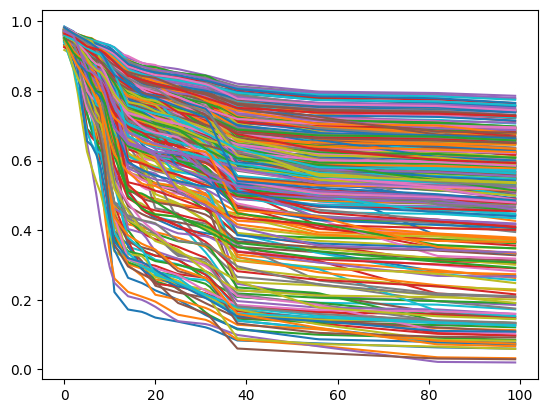

In [15]:
plt.plot(interpolated_probs.T)
# plt.plot(smoothed_interpolated_probs.T)
plt.show()

In [2]:
import pandas as pd
beta_acns331 = pd.read_csv('data/beta_acns331.csv', index_col=0)

In [4]:
cnv_acns331 = pd.read_csv('data/CNV_gene_acns331_20240115.csv', index_col=0)

In [5]:
cnv_acns331

,201985320231_R06C01,202234370003_R01C01,202234380104_R02C01,201985320231_R07C01,202816900043_R01C01,202234380093_R06C01,202784980019_R02C01,202234370058_R06C01,202234380076_R04C01,202784980019_R04C01,...,202234380096_R08C01,202234360015_R04C01,202234360015_R05C01,202234360015_R06C01,202234360015_R07C01,202234360015_R08C01,202234360020_R01C01,202234360020_R02C01,202234360020_R03C01,202234360020_R05C01
gene,,,,,,,,,,,,,,,,,,,,,
SAMD11,-0.249576,-0.116071,0.129206,-0.191692,0.159877,0.175200,-0.213307,-0.190943,-0.252978,-0.482781,...,-0.134341,-0.170365,-0.163226,-0.245435,-0.383662,-0.064768,-0.120218,0.214726,-0.178408,-0.272286
NOC2L,-0.135283,0.300233,-0.113898,-0.253591,0.017270,0.307009,-0.466859,-0.176450,-0.167592,-0.288356,...,-0.248501,0.023854,-0.198732,-0.197607,-0.504466,-0.254241,-0.060045,-0.061428,-0.091858,-0.274370
KLHL17,0.055906,0.039326,-0.001470,-0.141974,0.130177,0.302559,-0.003246,-0.178863,-0.171967,-0.436607,...,0.010309,-0.157517,-0.062009,-0.149621,-0.028304,-0.089555,-0.092587,0.129438,-0.060038,-0.215070
PLEKHN1,-0.325532,-0.414929,-0.002593,-0.196029,-0.274797,-0.043652,-0.491723,-0.345911,-0.274328,-0.882846,...,-0.633047,-0.434794,-0.620557,-0.329920,-0.366209,-0.349018,-0.284973,-0.654833,-0.018896,-0.673560
PERM1,-0.099830,0.021537,-0.110427,-0.107786,-0.073687,-0.087802,-0.355866,-0.095365,-0.105719,-0.095780,...,-0.258252,0.071270,-0.336320,-0.122114,0.147872,0.058599,-0.119053,-0.158729,-0.032287,-0.202927
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CHKB,0.127761,0.834555,0.216555,0.009999,0.280465,0.491116,0.151396,0.107100,-0.158112,-0.179533,...,0.183961,-0.373924,0.291581,0.035135,-0.346223,0.141362,0.095250,0.363833,-0.035763,0.227206
MAPK8IP2,-0.384211,-0.206720,0.297557,-0.187234,0.074709,-0.023757,-0.216398,-0.178602,-0.060526,-0.371475,...,-0.235376,-0.114719,-0.138973,-0.070861,0.031577,-0.104080,-0.009368,-0.298810,0.010492,-0.216542
ARSA,0.017979,0.155734,-0.426814,-0.220278,-0.247174,-0.361293,-0.565950,-0.173326,-0.513083,-0.257661,...,-0.133385,-0.466553,-0.131712,-0.390516,-0.464728,-0.195927,-0.132521,-0.120995,-0.127056,-0.307773
